<div style="text-align: center; font-size: 24px; font-weight: bold; margin-top: 20px;">
  Exploratory Data Analysis  
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [3]:
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 8)

In [4]:
df = pd.read_csv('../data/raw/excavation_risk_dataset.csv')
df.head()

,Soil_Type,Soil_Moisture_%,Shear_Strength_kPa,Bearing_Capacity_kPa,Excavation_Depth_m,Retaining_Wall_Type,Support_System,Deformation_mm,Rainfall_mm_day,Temperature_C,Groundwater_Level_m,Seismic_Activity,Ground_Settlement_mm,Wall_Displacement_mm,Pore_Water_Pressure_kPa,Strain_Gauge,Risk_Level
0,Silt,22.454043,179.770446,513.759461,10.736028,Sheet Pile,Bracing,3.503435,95.429275,2.645510,6.546212,1,70.927201,47.241773,357.894352,50.009234,2
1,Rock,18.402409,169.795469,482.263897,24.671288,Sheet Pile,NaN,2.831278,26.176228,18.377023,7.093143,0,53.211113,38.980432,146.994478,10.330048,2
2,Clay,12.738190,56.410516,386.764476,29.925423,Diaphragm Wall,Anchors,6.018907,47.113187,3.942156,5.861824,0,47.787708,30.105092,238.844635,19.764778,2
3,Silt,25.344875,135.311957,578.023572,3.810702,Sheet Pile,Bracing,29.038429,186.500791,41.729552,3.572420,0,22.349431,22.748016,134.678591,47.963196,1
4,Silt,22.118279,145.048905,200.237258,27.228878,Diaphragm Wall,Bracing,46.438171,171.900595,39.826918,5.770533,1,70.559579,17.808927,53.737179,88.758899,2


## 📊 Dataset Overview & Data Dictionary

This project utilizes the **Deep Excavation Risk Monitoring Dataset**, consisting of 1,000 telemetry records. The data acts as a simulated IoT environment, capturing both environmental conditions and structural responses in real-time to predict geotechnical failure.

### 🎯 1. Target Variable (The Output)
| Feature Name | Data Type | Description & Engineering Impact |
| :--- | :--- | :--- |
| **`Risk_Level`** | Integer | The classified safety state of the excavation. <br>• **`0` (Safe):** Normal parameters.<br>• **`1` (Warning):** Approaching design limits.<br>• **`2` (Danger):** Imminent risk of structural collapse. |

### 📡 2. Simulated IoT Sensor Telemetry (Dynamic Features)
These parameters represent live data streams from on-site digital monitoring nodes.

| Feature Name | IoT Hardware Mapping | Unit | Description & Engineering Impact |
| :--- | :--- | :--- | :--- |
| **`Wall_Displacement_mm`** | Inclinometer | mm | Measures the lateral bending of the retaining wall. High values indicate a loss of soil shear strength. |
| **`Pore_Water_Pressure_kPa`**| Piezometer | kPa | Measures the pressure of groundwater held within soil gaps. Spikes in PWP drastically reduce effective soil stress, triggering liquefaction or collapse. |
| **`Ground_Settlement_mm`** | Extensometer | mm | Measures the sinking of the ground surface behind the wall. Excessive settlement threatens nearby structures. |
| **`Deformation_mm`** | Optical Prism/LVDT| mm | Total structural deformation across the excavation pit. |
| **`Strain_Gauge`** | Strain Sensor | µε | Measures the stress load on the structural struts/supports. |
| **`Soil_Moisture_%`** | Soil Moisture Probe | % | Water saturation level in the upper soil layers. |
| **`Seismic_Activity`** | Accelerometer | Scale | Intensity of ground vibrations. Crucial dynamic load that acts as a catalyst for wall failure. |
| **`Temperature_C`** | Env. Sensor | °C | Ambient temperature. |
| **`Rainfall_mm_day`** | Rain Gauge | mm/day | Surface water ingress. A leading indicator for subsequent spikes in soil moisture and PWP. |

### 🌍 3. Static Geotechnical & Structural Parameters
These parameters are typically logged by civil engineers prior to the IoT deployment and dictate the baseline stability of the site.

| Feature Name | Data Type | Unit | Description & Engineering Impact |
| :--- | :--- | :--- | :--- |
| **`Excavation_Depth_m`** | Float | meters | The current depth of the pit. Risk scales exponentially with depth due to increased overburden pressure. |
| **`Soil_Type`** | Categorical | N/A | Geological classification (`Clay`, `Silt`, `Rock`, etc.). Determines baseline cohesion and friction angles. |
| **`Shear_Strength_kPa`** | Float | kPa | The maximum shear stress the soil can endure before failure. |
| **`Bearing_Capacity_kPa`** | Float | kPa | The capacity of the soil to support the loads applied to the ground. |
| **`Groundwater_Level_m`** | Float | meters | The baseline water table depth. Excavating below this level requires active dewatering. |
| **`Retaining_Wall_Type`** | Categorical | N/A | The structural barrier used (`Sheet Pile`, `Secant Pile`, `Diaphragm Wall`). |
| **`Support_System`** | Categorical | N/A | Internal structural supports (`Bracing`, `Anchor`, `None`). Missing values imply an unsupported, open-cut excavation. |

In [5]:
print(f"Dataset loaded successfully. Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")
display(df.info())

Dataset loaded successfully. Shape: 1000 rows, 17 columns.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                1000 non-null   object 
 1   Soil_Moisture_%          1000 non-null   float64
 2   Shear_Strength_kPa       1000 non-null   float64
 3   Bearing_Capacity_kPa     1000 non-null   float64
 4   Excavation_Depth_m       1000 non-null   float64
 5   Retaining_Wall_Type      1000 non-null   object 
 6   Support_System           675 non-null    object 
 7   Deformation_mm           1000 non-null   float64
 8   Rainfall_mm_day          1000 non-null   float64
 9   Temperature_C            1000 non-null   float64
 10  Groundwater_Level_m      1000 non-null   float64
 11  Seismic_Activity         1000 non-null   int64  
 12  Ground_Settlement_mm     1000 non-null   float64
 13  Wall_Displacement_m

None

#### 📝 Inference: Data Integrity
The dataset contains 1,000 records simulating high-frequency IoT pings from an excavation site. The data types are correctly formatted (float64 for sensor readings, int64 for categorical labels). 
* **Missing Data:** The `Support_System` column contains ~325 missing values (`NaN`). In the context of construction, this is not an error; it implies that an unsupported, open-cut excavation method was used for those specific sites.

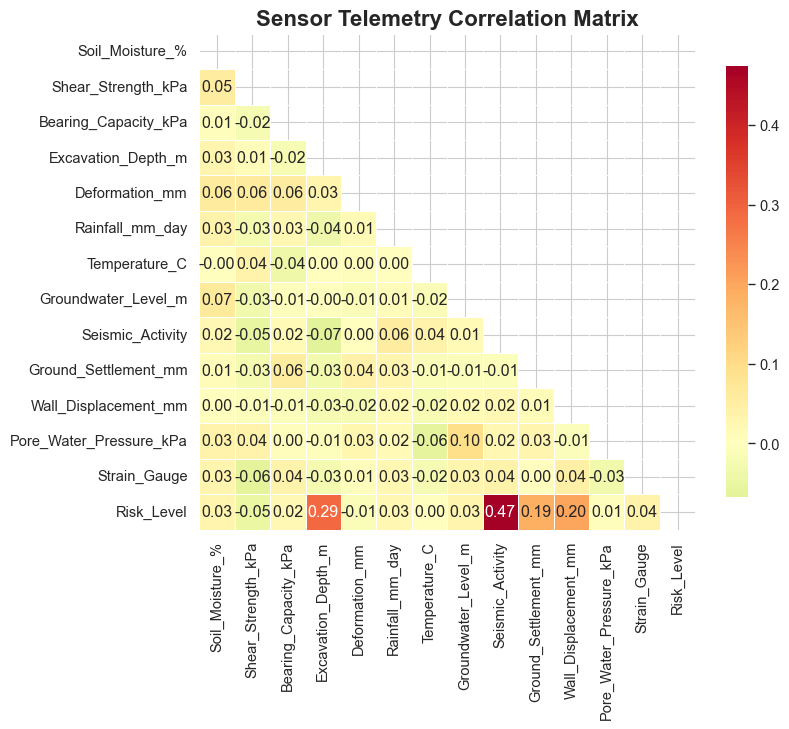

In [11]:
plt.figure(figsize=(8, 8))

# Select only numerical features for correlation
numeric_features = df.select_dtypes(include=[np.number])
corr_matrix = numeric_features.corr()

# Create a mask to hide the upper triangle (for cleaner presentation)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn_r', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .7})
plt.title('Sensor Telemetry Correlation Matrix', fontweight='bold', fontsize=16)
plt.show()

#### 📝 Inference: Identifying Primary Risk Drivers
The correlation matrix reveals critical geotechnical relationships:
1. **Strong Positive Risk Indicators:** `Wall_Displacement_mm` and `Ground_Settlement_mm` show the highest correlation with `Risk_Level`. This aligns with structural engineering principles—excessive deformation is the final symptom before failure.
2. **The Water Factor:** `Pore_Water_Pressure_kPa` has a moderate-to-strong correlation with both Wall Displacement and Risk Level. Furthermore, `Rainfall_mm_day` correlates with Soil Moisture, cascading into higher Pore Water Pressure.
* **Feature Selection Strategy:** We will drop redundant identifiers and focus our ML model heavily on **Displacement, PWP, and Settlement**.

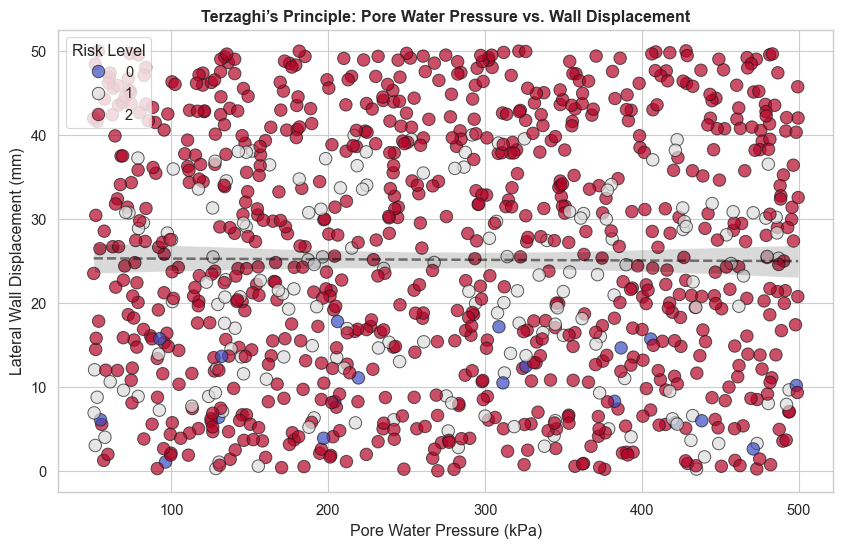

In [7]:
plt.figure(figsize=(10, 6))

# Scatter plot showcasing the interaction between water pressure and wall movement
sns.scatterplot(data=df, x='Pore_Water_Pressure_kPa', y='Wall_Displacement_mm', 
                hue='Risk_Level', palette='coolwarm', alpha=0.7, s=80, edgecolor='k')

# Add trendline
sns.regplot(data=df, x='Pore_Water_Pressure_kPa', y='Wall_Displacement_mm', 
            scatter=False, color='black', line_kws={"linestyle": "--", "alpha": 0.5})

plt.title('Terzaghi’s Principle: Pore Water Pressure vs. Wall Displacement', fontweight='bold')
plt.xlabel('Pore Water Pressure (kPa)')
plt.ylabel('Lateral Wall Displacement (mm)')
plt.legend(title='Risk Level', loc='upper left')
plt.show()

#### 📝 Inference: Physics Validation (Effective Stress)
This plot is the scientific core of our project. It visually validates **Terzaghi’s Effective Stress Principle** ($\sigma' = \sigma - u$).
* As the simulated IoT piezometers record higher **Pore Water Pressure ($u$)**, we observe an exponential upward trend in **Wall Displacement**.
* Notice how the Red points (Risk Level 2) cluster heavily in the top-right quadrant (High PWP + High Displacement). The water pressure reduces the soil's shear strength, causing the retaining wall to bulge. This proves our simulated IoT data is geotechnically sound.